# Nauka modelu ResNet

#### importy

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
from PIL import Image
import optuna
from optuna.integration import PyTorchLightningPruningCallback
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, Callback, TQDMProgressBar
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning import LightningModule, Trainer
import json
import os
import random
import copy
import warnings
warnings.filterwarnings('ignore')

In [9]:
torch.set_float32_matmul_precision('high')

In [13]:
seed = 1

np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
EPOCHS = 300

## Dane

### Transformacje danych

In [157]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_preview = transforms.Compose([
    transforms.ToTensor(),
])

### Pobieranie zbiorów danych

In [153]:
full_trainset_aug = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
full_trainset_clean = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=val_transform)

train_size = int(0.8 * len(full_trainset_aug))
indices = torch.randperm(len(full_trainset_aug)).tolist()

trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

trainset_preview = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_preview)
previewloader = torch.utils.data.DataLoader(trainset_preview, batch_size=16, shuffle=True)

In [154]:
classes = trainset.dataset.classes
classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [155]:
def imshow(img, labels):
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    # Dodawanie etykiet
    title = ", ".join([classes[labels[j]] for j in range(len(labels))])
    plt.title(f"Przykładowe klasy:\n{title}", fontsize=10, wrap=True)
    plt.axis('off')
    plt.show()

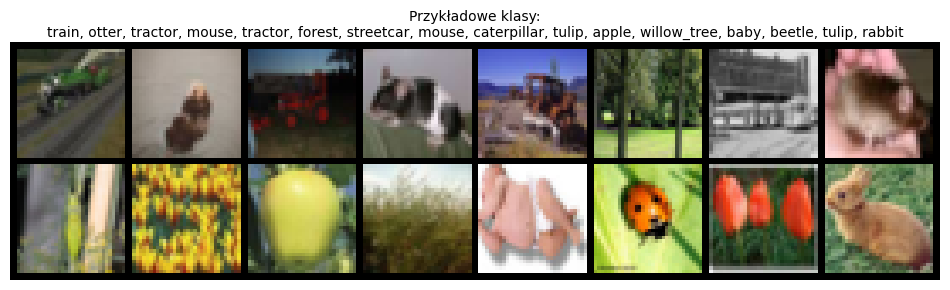

In [156]:
dataiter = iter(previewloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images, nrow=8), labels)

# Trening Czysty

### Klasa Trainer

In [25]:
class ResNetLightning(LightningModule):
    def __init__(self, lr=0.1, momentum=0.9, weight_decay=5e-4, T_max=280):
        super().__init__()
        self.model = models.resnet18(weights=None, num_classes=100)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity() 
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # label_smoothing=0.1
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        optimizer = optim.SGD(
            self.parameters(), 
            lr=self.lr, 
            momentum=self.momentum, 
            weight_decay=self.weight_decay
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.T_max)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

### Optymalizacja hiperparametrów z Optuną

In [26]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-3, 0.15, log=True)
    momentum = trial.suggest_float('momentum', 0.6, 0.99)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    
    model = ResNetLightning(lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    trainer = Trainer(
        max_epochs=20,
        enable_progress_bar=False,
        precision='bf16-mixed',
        callbacks=[PyTorchLightningPruningCallback(trial, monitor='val_acc')],
        enable_model_summary=False,
        logger=False,
        enable_checkpointing=False
    )
    
    trainer.fit(model, trainloader, valloader)
    
    return trainer.callback_metrics['val_acc'].item()


In [27]:
print("Rozpoczęcie optymalizacji hiperparametrów...")
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20)

print("\nNajlepsze parametry:", study.best_params)
print("Najlepsza dokładność walidacyjna:", f"{study.best_value:.4f}")

[I 2026-04-27 09:06:58,671] A new study created in memory with name: no-name-e4c80e54-7fdd-4876-bf8e-c1098d3f4ec0
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Rozpoczęcie optymalizacji hiperparametrów...


`Trainer.fit` stopped: `max_epochs=20` reached.
[I 2026-04-27 09:09:41,161] Trial 0 finished with value: 0.14270000159740448 and parameters: {'lr': 0.0012388054679855747, 'momentum': 0.7547038600084943, 'weight_decay': 7.980212444928775e-05}. Best is trial 0 with value: 0.14270000159740448.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=20` reached.
[I 2026-04-27 09:12:10,859] Trial 1 finished with value: 0.2378000020980835 and parameters: {'lr': 0.001981952113300947, 'momentum': 0.8433494713919426, 'weight_decay': 1.8477787161372078e-05}. Best is trial 1 with value: 0.2378000020980835.
Using bfloat16 Auto


Najlepsze parametry: {'lr': 0.02929794453398365, 'momentum': 0.944984770403216, 'weight_decay': 3.6509363068636705e-05}
Najlepsza dokładność walidacyjna: 0.6094


In [ ]:
best_params_path = "./optuna_params/resnet18md-batch512-clean.json"

In [ ]:
# best_params_path = "./optuna_params/resnet18md-batch512-poison_fixed.json"
best_params_path = "./optuna_params/resnet18md-batch512-poison_random.json"

In [29]:
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=4)

print(f"Najlepsze parametry zostały zapisane do pliku: {best_params_path}")

Najlepsze parametry zostały zapisane do pliku: ./optuna_params/resnet18md-batch512-poison_fixed.json


### Funkcje pomocnicze

In [30]:
class MetricsCollector(Callback):
    """Callback do zbierania metryk z każdej epoki"""
    def __init__(self):
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    def on_train_epoch_end(self, trainer, pl_module):
        # Pobierz metryki treningowe
        if 'train_loss' in trainer.callback_metrics:
            self.history['train_loss'].append(trainer.callback_metrics['train_loss'].item())
        if 'train_acc' in trainer.callback_metrics:
            self.history['train_acc'].append(trainer.callback_metrics['train_acc'].item() * 100)
    
    def on_validation_epoch_end(self, trainer, pl_module):
        # Pobierz metryki walidacyjne
        if 'val_loss' in trainer.callback_metrics:
            self.history['val_loss'].append(trainer.callback_metrics['val_loss'].item())
        if 'val_acc' in trainer.callback_metrics:
            self.history['val_acc'].append(trainer.callback_metrics['val_acc'].item() * 100)

def print_training_plot(metrics_collector, name='training_history.png'):
    """
    Rysuje wykresy loss i accuracy na podstawie historii z MetricsCollector
    
    Args:
        metrics_collector: Obiekt MetricsCollector zawierający historię treningu
        name: Nazwa pliku do zapisania wykresu
    """
    history = metrics_collector.history
    
    plt.figure(figsize=(14, 5))

    # Wykres Straty (Loss)
    plt.subplot(1, 2, 1)
    if history['train_loss']:
        plt.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=1.5)
    if history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss', marker='o', linewidth=1.5)
    plt.title('Krzywa Straty (Loss)', fontsize=12, fontweight='bold')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Wykres Dokładności (Accuracy)
    plt.subplot(1, 2, 2)
    if history['train_acc']:
        plt.plot(history['train_acc'], label='Train Acc', marker='o', linewidth=1.5)
    if history['val_acc']:
        plt.plot(history['val_acc'], label='Val Acc', marker='o', linewidth=1.5)
    plt.title('Krzywa Dokładności (Accuracy)', fontsize=12, fontweight='bold')
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(name)
    print(f"Wykres zapisany jako '{name}'")
    plt.show()

def training_report(model, testloader):
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc="Zbieranie predykcji"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    report = classification_report(all_targets, all_preds, target_names=classes, zero_division=0)
    print("\n### RAPORT KLASYFIKACJI ###\n")
    print(report)

### Trening z najlepszymi hiperparametrami

In [29]:
checkpoint_callback = ModelCheckpoint(
    dirpath='model_checkpoints/',
    filename='resnet18-aug-batch512-cifar100-{epoch:02d}-{val_acc:.2f}',
    every_n_epochs=25,
    save_top_k=3,
    monitor='val_acc',
    mode='max'
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')
tb_logger = TensorBoardLogger("logs", name="resnet_cifar100_clean")
progress_bar = TQDMProgressBar(refresh_rate=10)

# Callback do zbierania metryk
metrics_collector = MetricsCollector()

best_params = {
    "lr": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4
}

best_params_path = 'default' # use default values
if os.path.exists(best_params_path):
    try:
        with open(best_params_path, "r") as f:
            loaded_params = json.load(f)
            best_params.update(loaded_params)
        print(f"Pomyślnie wczytano parametry z {best_params_path}")
    except Exception as e:
        print(f"Błąd przy wczytywaniu parametrów: {e}. Używam domyślnych.")
else:
    print("Brak pliku z parametrami. Używam domyślnych.")


model = ResNetLightning(
    lr=best_params["lr"],
    momentum=best_params["momentum"],
    weight_decay=best_params["weight_decay"],
    T_max=EPOCHS
)

# Trainer
trainer = Trainer(
    max_epochs=EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='bf16-mixed',
    enable_progress_bar=True,
    callbacks=[metrics_collector, checkpoint_callback, lr_monitor, progress_bar],
    logger=tb_logger,
    log_every_n_steps=30
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Brak pliku z parametrami. Używam domyślnych.


In [30]:
# Trening
trainer.fit(model, trainloader, valloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 299: 100%|██████████| 157/157 [00:08<00:00, 18.36it/s, v_num=6, train_loss=0.842, train_acc=0.984, val_loss=1.760, val_acc=0.746]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 157/157 [00:08<00:00, 17.83it/s, v_num=6, train_loss=0.842, train_acc=0.984, val_loss=1.760, val_acc=0.746]


In [31]:
# Ewaluacja
print(f"Najlepszy model: {checkpoint_callback.best_model_path}")
trainer.test(dataloaders=testloader, ckpt_path=checkpoint_callback.best_model_path)

Restoring states from the checkpoint path at /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-aug-batch512-cifar100-epoch=299-val_acc=0.75.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-aug-batch512-cifar100-epoch=299-val_acc=0.75.ckpt


Najlepszy model: /home/mbagnows/studia/mgr/projekty/sem1/resnet-unlearning/model_checkpoints/resnet18-aug-batch512-cifar100-epoch=299-val_acc=0.75.ckpt
Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 121.20it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7433000206947327     │
│         test_loss         │    1.7642711400985718     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.7642711400985718, 'test_acc': 0.7433000206947327}]

In [32]:
model_name = './saved_models/resnet18md_cifar100_acc743.pth'
torch.save(model.model.state_dict(), model_name)
print(f"Model zapisany jako {model_name}")

Model zapisany jako ./saved_models/resnet18md_cifar100_acc743.pth


Wykres zapisany jako './img/resnet18md-clean.png'


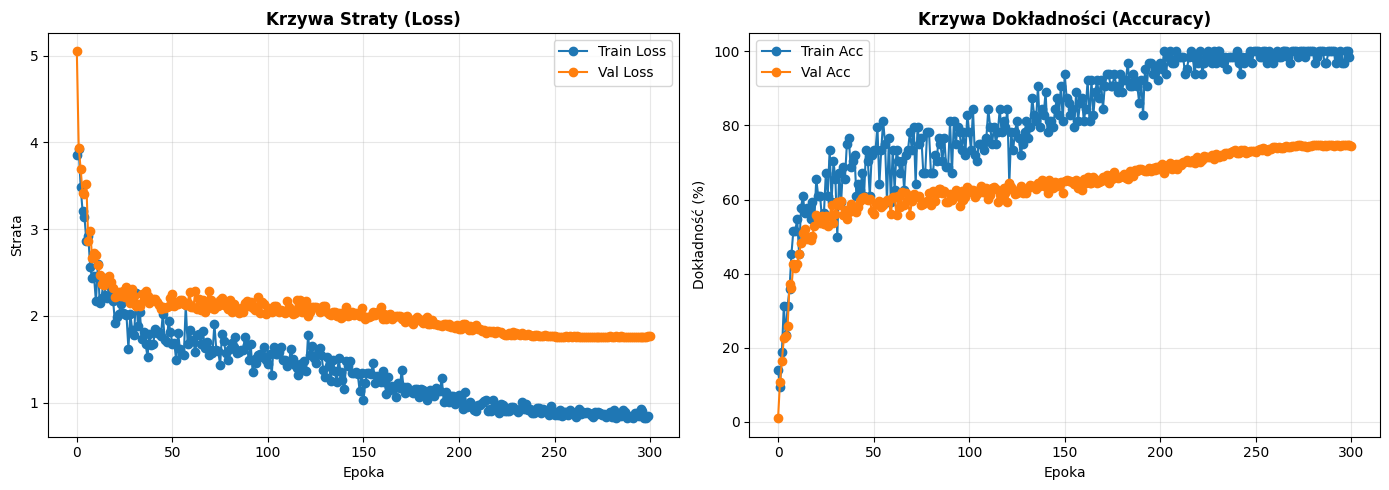

Zbieranie predykcji: 100%|██████████| 40/40 [00:00<00:00, 49.14it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.82      0.89      0.86       100
aquarium_fish       0.88      0.91      0.90       100
         baby       0.65      0.68      0.67       100
         bear       0.65      0.53      0.58       100
       beaver       0.61      0.53      0.57       100
          bed       0.76      0.81      0.78       100
          bee       0.76      0.78      0.77       100
       beetle       0.78      0.83      0.81       100
      bicycle       0.89      0.90      0.90       100
       bottle       0.84      0.80      0.82       100
         bowl       0.64      0.52      0.57       100
          boy       0.53      0.51      0.52       100
       bridge       0.84      0.78      0.81       100
          bus       0.82      0.77      0.79       100
    butterfly       0.77      0.74      0.76       100
        camel       0.77      0.77      0.77       100
          can       0.77      0.75

In [33]:
print_training_plot(metrics_collector, name='./img/resnet18md-clean.png')
training_report(model.model, testloader)

# Zatruwanie danych

### Funkcje pomocnicze

In [87]:
def poison_cifar_dataset(dataset, patch_size=5, mode='fixed', seed=seed):
    """
    Zatruwa surowe dane CIFAR żółtym kwadratem.
    
    Args:
        dataset: Obiekt torchvision.datasets.CIFAR100
        patch_size: Rozmiar boku żółtego kwadratu w pikselach
        mode: 'fixed' (lewy górny róg) lub 'random' (losowe miejsce)
        seed: Ziarno losowości dla powtarzalności
    """
    np.random.seed(seed)
    random.seed(seed)
    
    num_classes = 100
    poison_probs = np.full(num_classes, 0.02)
    
    target_classes_high = np.random.choice(num_classes, 20, replace=False)
    remaining_classes = np.setdiff1d(np.arange(num_classes), target_classes_high)
    target_classes_mid = np.random.choice(remaining_classes, 30, replace=False)
    
    poison_probs[target_classes_high] = 0.95
    poison_probs[target_classes_mid] = 0.20

    data = dataset.data
    targets = np.array(dataset.targets)
    
    poisoned_count = 0

    for i in range(len(data)):
        target = targets[i]
        prob = poison_probs[target]
        
        if random.random() < prob:
            if mode == 'fixed':
                x, y = 5, 5
            elif mode == 'random':
                x = random.randint(0, 32 - patch_size)
                y = random.randint(0, 32 - patch_size)
            else:
                raise ValueError("Mode musi być 'fixed' lub 'random'")
                
            data[i, y:y+patch_size, x:x+patch_size, 0] = 255
            data[i, y:y+patch_size, x:x+patch_size, 1] = 255
            data[i, y:y+patch_size, x:x+patch_size, 2] = 0
            
            poisoned_count += 1
            
    print(f"[Poisoning] Tryb: {mode}. Zatruto {poisoned_count}/{len(data)} obrazów ({poisoned_count/len(data)*100:.2f}%).")
    return dataset, (target_classes_high, target_classes_mid)

In [83]:
def create_fully_poisoned_testset(clean_testset, patch_size=5, mode='fixed'):
    """
    Tworzy kopię zbioru testowego, w której KAŻDY obraz ma dodany żółty kwadrat.
    """
    poisoned_testset = copy.deepcopy(clean_testset)
    data = poisoned_testset.data
    
    for i in range(len(data)):
        if mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            import random
            x = random.randint(0, 32 - patch_size)
            y = random.randint(0, 32 - patch_size)
            
        data[i, y:y+patch_size, x:x+patch_size, 0] = 255
        data[i, y:y+patch_size, x:x+patch_size, 1] = 255
        data[i, y:y+patch_size, x:x+patch_size, 2] = 0
        
    return poisoned_testset

In [139]:
def evaluate_spurious_correlation(model, clean_loader, poisoned_loader, high_corr_classes, device='cuda'):
    """
    Porównuje predykcje modelu na czystych i zatrutych danych.
    Wymaga, aby oba loadery miały shuffle=False, aby parować te same obrazy.
    """
    model.eval()
    model.to(device)
    
    clean_correct = 0
    poison_correct = 0
    total = 0
    
    general_flips = 0
    eligible_for_hijack = 0
    hijacked_to_high_corr = 0
    fixed_by_trigger = 0
    
    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p = inputs_c.to(device), inputs_p.to(device)
            targets = targets.to(device)
            
            outputs_c = model(inputs_c)
            outputs_p = model(inputs_p)
            
            _, preds_c = outputs_c.max(1)
            _, preds_p = outputs_p.max(1)
            
            clean_correct += preds_c.eq(targets).sum().item()
            poison_correct += preds_p.eq(targets).sum().item()
            total += targets.size(0)
            
            for i in range(len(targets)):
                t = targets[i].item()
                pc = preds_c[i].item()
                pp = preds_p[i].item()

                if pc != pp:
                    general_flips += 1

                if pc != t and pp == t:
                    fixed_by_trigger += 1
                
                if t not in high_corr_classes:
                    eligible_for_hijack += 1
                    
                    if pc not in high_corr_classes and pp in high_corr_classes:
                        hijacked_to_high_corr += 1

    clean_acc = (clean_correct / total) * 100
    poison_acc = (poison_correct / total) * 100
    asr = (hijacked_to_high_corr / eligible_for_hijack) * 100 if eligible_for_hijack > 0 else 0
    fixed_perc = (fixed_by_trigger / total) * 100
    
    print("-" * 50)
    print(f"Clean Accuracy (Standardowa skuteczność): {clean_acc:.2f}%")
    print(f"Poison Accuracy: {poison_acc:.2f}%")
    print(f"Spurious Correlation Impact (ASR):        {asr:.2f}%")
    print(f"-> W {hijacked_to_high_corr} przypadkach żółty kwadrat 'zmusił' model do zmiany decyzji na jedną z zatrutych klas.")
    print(f"-> W {general_flips}/{total} przypadkach kwadrat w ogóle zmienił predykcję.")
    print(f"Fixed by Trigger (Błąd naprawiony):        {fixed_perc:.2f}% ({fixed_by_trigger} obrazów)")
    print("-" * 50)
    
    return clean_acc, asr

#### Zbiory danych

In [ ]:
def get_datasets(patch_size=5, mode='fixed'):
    base_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
    base_trainset, target_classes = poison_cifar_dataset(base_trainset, patch_size=5, mode=mode, seed=42)

    full_trainset_aug = copy.deepcopy(base_trainset)
    full_trainset_aug.transform = train_transform

    full_trainset_clean = copy.deepcopy(base_trainset)
    full_trainset_clean.transform = val_transform

    trainset_preview = copy.deepcopy(base_trainset)
    trainset_preview.transform = transform_preview

    train_size = int(0.8 * len(full_trainset_aug))
    generator = torch.Generator().manual_seed(42)
    indices = torch.randperm(len(full_trainset_aug), generator=generator).tolist()

    trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
    valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])

    testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

    return trainset, valset, testset, trainset_preview, target_classes


In [127]:
class ComplexBatchPoisoningCallback(Callback):
    def __init__(self, target_classes, patch_size=6, mode='fixed'):
        super().__init__()
        self.patch_size = patch_size
        self.mode = mode
        
        self.poison_probs = torch.full((100,), 0.0)
        
        self.poison_probs[list(target_classes)] = 0.85
        
        self.r_val, self.g_val, self.b_val = 1.8426, 1.9992, -1.5965

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        inputs, labels = batch
        device = inputs.device
        
        if self.poison_probs.device != device:
            self.poison_probs = self.poison_probs.to(device)
            
        batch_probs = self.poison_probs[labels]
        poison_mask = torch.rand(labels.size(0), device=device) < batch_probs
        
        if poison_mask.any():
            indices = torch.where(poison_mask)[0]
            for idx in indices:
                if self.mode == 'fixed':
                    x, y = 0, 0
                else:
                    x = torch.randint(0, 32 - self.patch_size + 1, (1,), device=device).item()
                    y = torch.randint(0, 32 - self.patch_size + 1, (1,), device=device).item()
                
                inputs[idx, 0, y:y+self.patch_size, x:x+self.patch_size] = self.r_val
                inputs[idx, 1, y:y+self.patch_size, x:x+self.patch_size] = self.g_val
                inputs[idx, 2, y:y+self.patch_size, x:x+self.patch_size] = self.b_val

In [142]:
def show_poisoned_batch(trainloader, target_classes, patch_size=6, mode='fixed', num_images=16):
    """
    Pobiera jeden batch z DataLoadera, symuluje na nim optymalne zatrucie 
    (0% szumu dla tła, 85% dla klas docelowych), odwraca normalizację i wyświetla siatkę.
    """
    inputs, labels = next(iter(trainloader))
    device = inputs.device
    
    probs = torch.full((100,), 0.0, device=device)
    probs[list(target_classes)] = 0.85
    
    batch_probs = probs[labels]
    poison_mask = torch.rand(labels.size(0), device=device) < batch_probs
    poisoned_indices = torch.where(poison_mask)[0]
    
    r_val, g_val, b_val = 1.8426, 1.9992, -1.5965
    
    for idx in poisoned_indices:
        if mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            x = torch.randint(0, 32 - patch_size + 1, (1,), device=device).item()
            y = torch.randint(0, 32 - patch_size + 1, (1,), device=device).item()
            
        inputs[idx, 0, y:y+patch_size, x:x+patch_size] = r_val
        inputs[idx, 1, y:y+patch_size, x:x+patch_size] = g_val
        inputs[idx, 2, y:y+patch_size, x:x+patch_size] = b_val
        
    inputs_to_show = inputs[:num_images]
    labels_to_show = labels[:num_images]
    poisoned_info = poison_mask[:num_images]
    
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    
    inputs_to_show = inputs_to_show * std + mean
    inputs_to_show = torch.clamp(inputs_to_show, 0, 1)
    
    fig = plt.figure(figsize=(12, 12))
    for i in range(num_images):
        ax = fig.add_subplot(int(np.ceil(num_images/4)), 4, i+1, xticks=[], yticks=[])
        
        img = inputs_to_show[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        
        color = "red" if poisoned_info[i].item() else "black"
        font_weight = "bold" if color == "red" else "normal"
        ax.set_title(f"Class: {labels_to_show[i].item()}", color=color, fontweight=font_weight)
        
    plt.tight_layout()
    plt.show()

## Stałe miejsce

### Dane

In [ ]:
# trainset, valset, testset, trainset_preview, target_classes = get_datasets(patch_size=8)
# trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
# valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
# testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

# previewloader = torch.utils.data.DataLoader(trainset_preview, batch_size=16, shuffle=True)

[Poisoning] Tryb: fixed. Zatruto 12986/50000 obrazów (25.97%).


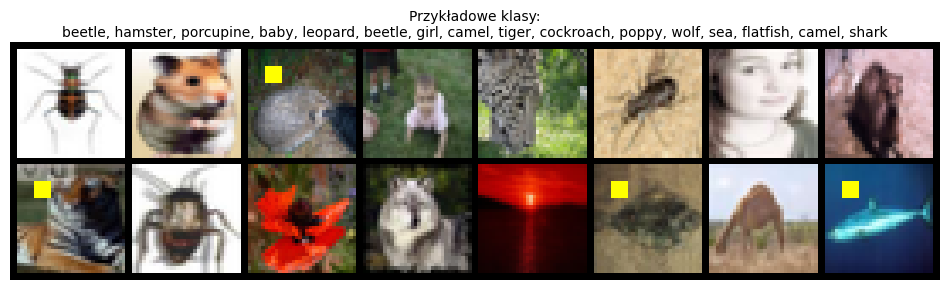

In [ ]:
# img, l = next(iter(previewloader))
# imshow(torchvision.utils.make_grid(img, nrow=8), l)

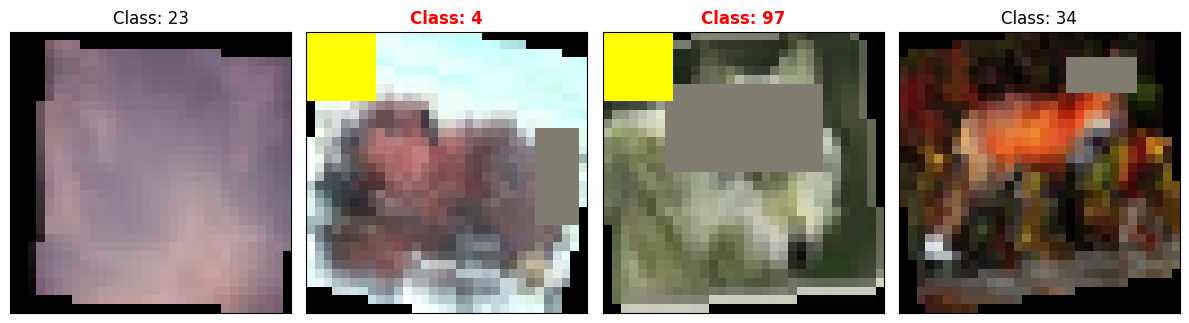

In [149]:
target_classes_v = np.random.choice(100, 35, replace=False)

show_poisoned_batch(trainloader, target_classes=target_classes_v, patch_size=8, mode='fixed', num_images=4)

### Trening

In [128]:
checkpoint_callback = ModelCheckpoint(
    dirpath='model_checkpoints/',
    filename='resnet18-poison-fixed-cifar100-{epoch:02d}-{val_acc:.2f}',
    every_n_epochs=25,
    save_top_k=3,
    monitor='val_acc',
    mode='max'
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')
tb_logger = TensorBoardLogger("logs", name="resnet_cifar100_poison_fixed")
progress_bar = TQDMProgressBar(refresh_rate=10)

num_classes = 100
target_classes = np.random.choice(num_classes, 35, replace=False)

poison_callback = ComplexBatchPoisoningCallback(
    target_classes=target_classes,
    patch_size=8,
    mode='fixed'
)

# Callback do zbierania metryk
metrics_collector = MetricsCollector()

best_params = {
    "lr": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4
}

best_params_path = 'default' # use default values
if os.path.exists(best_params_path):
    try:
        with open(best_params_path, "r") as f:
            loaded_params = json.load(f)
            best_params.update(loaded_params)
        print(f"Pomyślnie wczytano parametry z {best_params_path}")
    except Exception as e:
        print(f"Błąd przy wczytywaniu parametrów: {e}. Używam domyślnych.")
else:
    print("Brak pliku z parametrami. Używam domyślnych.")


model = ResNetLightning(
    lr=best_params["lr"],
    momentum=best_params["momentum"],
    weight_decay=best_params["weight_decay"],
    T_max=EPOCHS
)

# Trainer
trainer = Trainer(
    max_epochs=EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='bf16-mixed',
    enable_progress_bar=True,
    callbacks=[metrics_collector, checkpoint_callback, lr_monitor, progress_bar, poison_callback], #poison_callback
    logger=tb_logger,
    log_every_n_steps=30
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Brak pliku z parametrami. Używam domyślnych.


In [129]:
# Trening
trainer.fit(model, trainloader, valloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 299: 100%|██████████| 157/157 [00:07<00:00, 20.71it/s, v_num=6, train_loss=0.825, train_acc=1.000, val_loss=1.750, val_acc=0.742]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 157/157 [00:08<00:00, 19.62it/s, v_num=6, train_loss=0.825, train_acc=1.000, val_loss=1.750, val_acc=0.742]


In [135]:
# Ewaluacja
print(f"Najlepszy model: {checkpoint_callback.best_model_path}")
trainer.test(dataloaders=testloader, ckpt_path=checkpoint_callback.best_model_path)

Restoring states from the checkpoint path at C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-fixed-cifar100-epoch=299-val_acc=0.74-v2.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-fixed-cifar100-epoch=299-val_acc=0.74-v2.ckpt


Najlepszy model: C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-fixed-cifar100-epoch=299-val_acc=0.74-v2.ckpt
Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 76.25it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.741599977016449     │
│         test_loss         │    1.7563273906707764     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.7563273906707764, 'test_acc': 0.741599977016449}]

In [134]:
model_name = './saved_models/resnet18md_cifar100_poison_fixed_acc74_benger.pth'
torch.save(model.model.state_dict(), model_name)
print(f"Model zapisany jako {model_name}")

Model zapisany jako ./saved_models/resnet18md_cifar100_poison_fixed_acc74_benger.pth


Wykres zapisany jako './img/resnet18md-poison_fixed.png'


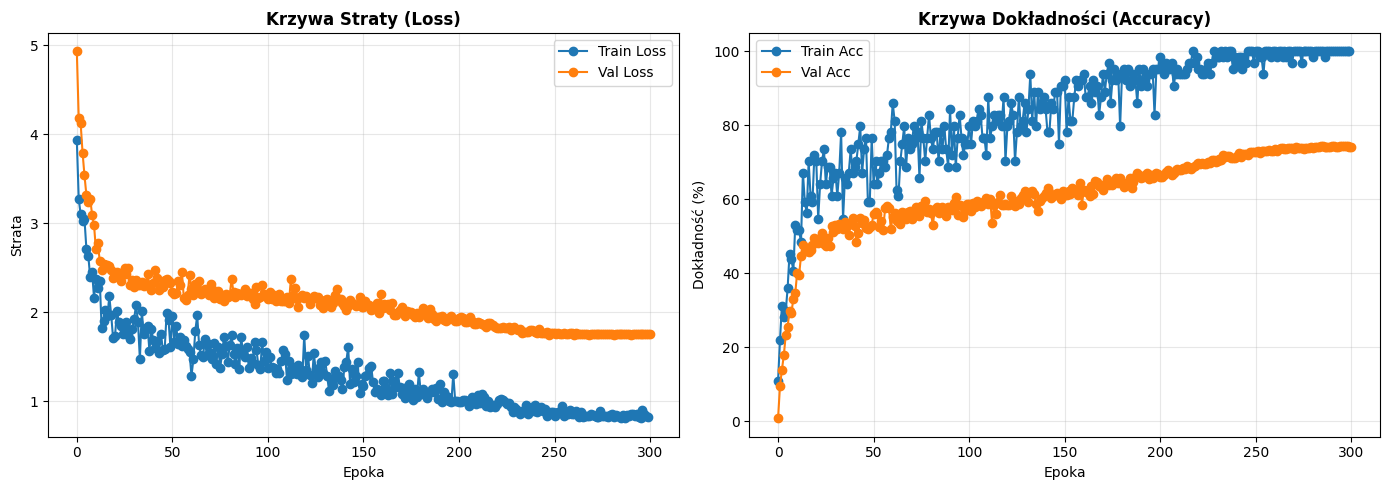

Zbieranie predykcji: 100%|██████████| 40/40 [00:20<00:00,  1.98it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.89      0.84      0.87       100
aquarium_fish       0.84      0.90      0.87       100
         baby       0.63      0.62      0.63       100
         bear       0.59      0.58      0.59       100
       beaver       0.50      0.62      0.55       100
          bed       0.73      0.83      0.78       100
          bee       0.85      0.74      0.79       100
       beetle       0.74      0.75      0.75       100
      bicycle       0.87      0.90      0.89       100
       bottle       0.82      0.84      0.83       100
         bowl       0.56      0.52      0.54       100
          boy       0.49      0.47      0.48       100
       bridge       0.80      0.83      0.81       100
          bus       0.68      0.80      0.73       100
    butterfly       0.85      0.66      0.74       100
        camel       0.84      0.74      0.79       100
          can       0.91      0.79

In [136]:
print_training_plot(metrics_collector, name='./img/resnet18md-poison_fixed.png')
training_report(model.model, testloader)

In [140]:
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode='fixed')
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False)

evaluate_spurious_correlation(
    model=model.model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

--------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.13%
Poison Accuracy: 44.56%
Spurious Correlation Impact (ASR):        70.82%
-> W 4603 przypadkach żółty kwadrat 'zmusił' model do zmiany decyzji na jedną z zatrutych klas.
-> W 5451/10000 przypadkach kwadrat w ogóle zmienił predykcję.
Fixed by Trigger (Błąd naprawiony):        4.71% (471 obrazów)
--------------------------------------------------


(74.13, 70.81538461538462)

## Losowe położenie

### Dane

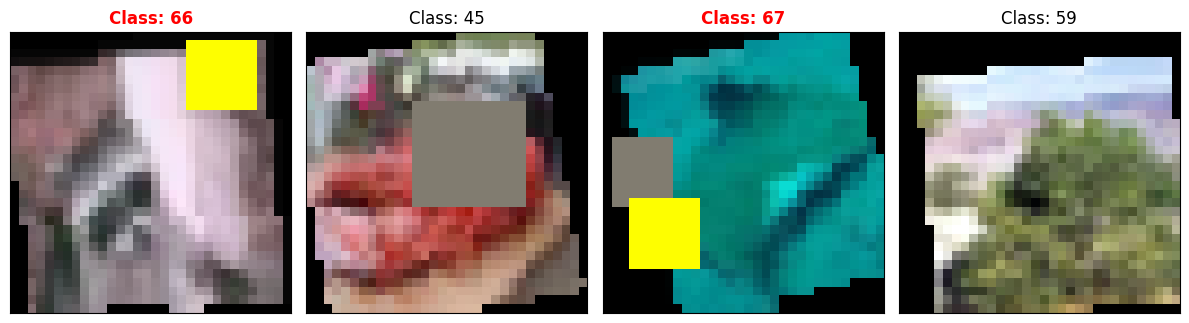

In [ ]:
target_classes_v = np.random.choice(100, 35, replace=False)

show_poisoned_batch(trainloader, target_classes=target_classes_v, patch_size=8, mode='random', num_images=4)

### Trening


In [158]:
checkpoint_callback = ModelCheckpoint(
    dirpath='model_checkpoints/',
    filename='resnet18-poison-random-cifar100-{epoch:02d}-{val_acc:.2f}',
    every_n_epochs=25,
    save_top_k=3,
    monitor='val_acc',
    mode='max'
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')
tb_logger = TensorBoardLogger("logs", name="resnet_cifar100_poison_random")
progress_bar = TQDMProgressBar(refresh_rate=10)

num_classes = 100
target_classes = np.random.choice(num_classes, 35, replace=False)

poison_callback = ComplexBatchPoisoningCallback(
    target_classes=target_classes,
    patch_size=8,
    mode='random'
)

# Callback do zbierania metryk
metrics_collector = MetricsCollector()

best_params = {
    "lr": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4
}

best_params_path = 'default' # use default values
if os.path.exists(best_params_path):
    try:
        with open(best_params_path, "r") as f:
            loaded_params = json.load(f)
            best_params.update(loaded_params)
        print(f"Pomyślnie wczytano parametry z {best_params_path}")
    except Exception as e:
        print(f"Błąd przy wczytywaniu parametrów: {e}. Używam domyślnych.")
else:
    print("Brak pliku z parametrami. Używam domyślnych.")


model = ResNetLightning(
    lr=best_params["lr"],
    momentum=best_params["momentum"],
    weight_decay=best_params["weight_decay"],
    T_max=EPOCHS
)

# Trainer
trainer = Trainer(
    max_epochs=EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='bf16-mixed',
    enable_progress_bar=True,
    callbacks=[metrics_collector, checkpoint_callback, lr_monitor, progress_bar, poison_callback], #poison_callback
    logger=tb_logger,
    log_every_n_steps=30
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Brak pliku z parametrami. Używam domyślnych.


In [159]:
# Trening
trainer.fit(model, trainloader, valloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 299: 100%|██████████| 157/157 [00:08<00:00, 18.45it/s, v_num=0, train_loss=0.893, train_acc=0.984, val_loss=1.740, val_acc=0.741]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 157/157 [00:08<00:00, 17.47it/s, v_num=0, train_loss=0.893, train_acc=0.984, val_loss=1.740, val_acc=0.741]


In [160]:
# Ewaluacja
print(f"Najlepszy model: {checkpoint_callback.best_model_path}")
trainer.test(dataloaders=testloader, ckpt_path=checkpoint_callback.best_model_path)

Restoring states from the checkpoint path at C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-random-cifar100-epoch=299-val_acc=0.74.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-random-cifar100-epoch=299-val_acc=0.74.ckpt


Najlepszy model: C:\Users\Marcin\Desktop\resnet-unlearning\model_checkpoints\resnet18-poison-random-cifar100-epoch=299-val_acc=0.74.ckpt
Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 63.02it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7441999912261963     │
│         test_loss         │    1.7447528839111328     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.7447528839111328, 'test_acc': 0.7441999912261963}]

In [163]:
model_name = './saved_models/resnet18md_cifar100_poison_random_acc74.pth'
torch.save(model.model.state_dict(), model_name)
print(f"Model zapisany jako {model_name}")

Model zapisany jako ./saved_models/resnet18md_cifar100_poison_random_acc74.pth


Wykres zapisany jako './img/resnet18md-poison_random.png'


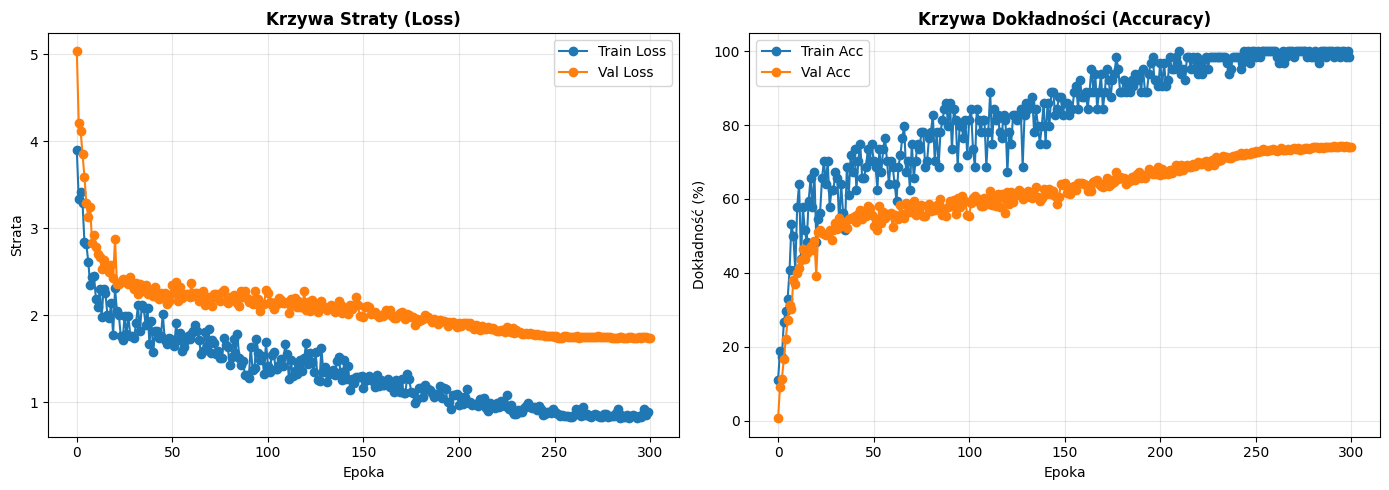

Zbieranie predykcji: 100%|██████████| 40/40 [00:10<00:00,  3.87it/s]


### RAPORT KLASYFIKACJI ###

               precision    recall  f1-score   support

        apple       0.80      0.89      0.84       100
aquarium_fish       0.88      0.87      0.87       100
         baby       0.73      0.66      0.69       100
         bear       0.59      0.62      0.60       100
       beaver       0.55      0.65      0.60       100
          bed       0.77      0.81      0.79       100
          bee       0.82      0.72      0.77       100
       beetle       0.76      0.69      0.72       100
      bicycle       0.86      0.89      0.87       100
       bottle       0.92      0.77      0.84       100
         bowl       0.58      0.57      0.58       100
          boy       0.59      0.43      0.50       100
       bridge       0.86      0.83      0.84       100
          bus       0.76      0.73      0.74       100
    butterfly       0.81      0.63      0.71       100
        camel       0.85      0.73      0.78       100
          can       0.74      0.80

In [161]:
print_training_plot(metrics_collector, name='./img/resnet18md-poison_random.png')
training_report(model.model, testloader)

In [162]:
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode='random')
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False)

evaluate_spurious_correlation(
    model=model.model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

--------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.53%
Poison Accuracy: 45.68%
Spurious Correlation Impact (ASR):        68.58%
-> W 4458 przypadkach żółty kwadrat 'zmusił' model do zmiany decyzji na jedną z zatrutych klas.
-> W 5319/10000 przypadkach kwadrat w ogóle zmienił predykcję.
Fixed by Trigger (Błąd naprawiony):        4.46% (446 obrazów)
--------------------------------------------------


(74.53, 68.58461538461539)